# SMG perturbation output — validation notebook

Tests the `delta_smg`, `theta_smg`, `shear_smg`, `mu`, `gamma` quantities
added to the MochiCLASS perturbation output.

## Context

The installed `_classy.so` was compiled from the **pre-fix** source:
- The metric quantities `h_prime`, `eta`, `alpha`, … are **zero** in the Python
  output (they were inside the dead `if (0==1)` block).
- The key called `h_prime` in Python actually holds **H_T_prime** data
  (column-ordering mismatch between titles and data).
- The `class` binary **has** been rebuilt with the fixes; the file output is
  correct. Rebuild the Python extension to align them.

Quantities that **do work** correctly in the installed Python interface:
`delta_smg`, `theta_smg`, `shear_smg`, `mu`, `gamma`, and all matter/radiation
density/velocity fields.

## Tests
1. **LCDM limit** — `delta_smg = theta_smg = shear_smg = 0` when w = -1
2. **QSA couplings** — `mu ≈ 1`, `gamma ≈ 1` in GR/stable-params limit
3. **Matter sector** — `delta_cdm`, `delta_b`, `delta_g` consistent across models
4. **CPL QSA stability** — diagnose `mass2_qs` and `V_x_smg` for CPL parameters
5. **Binary output** — read the `class`-binary file to check the fixed metric columns


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
import scienceplots

plt.style.use(['science', 'bright', 'vpedre', 'no-latex'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

: 

In [2]:
# GR stable_params file: tiny DeltaM2 = Dkin = 1e-4  (nearly GR)
deltalna  = 7.5e-4
lna_start = -5
lna_end   = 0.25
N = int((lna_end - lna_start) / deltalna) + 1

lna_smg = np.linspace(lna_start, lna_end, N)
data = np.column_stack((lna_smg, np.full(N, 1e-4), np.full(N, 1e-4), np.ones(N)))
np.savetxt('../stable_params_input/gr.dat', data, delimiter=' ')
print('gr.dat written')

gr.dat written


In [ ]:
def make_w0wa_stable_params(w0, wa, filename,
                             Omega_b=0.049, Omega_cdm=0.27,
                             DeltaM2=1e-4, cs2=1.0, Dkin_floor=1e-4,
                             lna_start=-5.0, lna_end=0.25, deltalna=7.5e-4):
    """
    Write a stable_params input file for w(a) = w0 + wa*(1 - a) in the GR limit.

    Columns: lna | DeltaM2 | Dkin | cs2

    For a canonical quintessence field the kinematic stability parameter is
        Dkin(a) = alphaK(a) = (1 + w(a)) * Omega_DE(a)
    where Omega_DE(a) is computed from the CPL background (exact analytical integral).
    The result is floored at Dkin_floor so that LCDM (w = -1) and phantom (w < -1)
    cases remain numerically well-conditioned without triggering a QSA divergence.

    Parameters
    ----------
    w0, wa      : CPL parameters  w(a) = w0 + wa*(1 - a)
    filename    : output path for the .dat file
    Omega_b/cdm : baryon / CDM density today (flat FLRW, radiation neglected)
    DeltaM2     : M*^2 - 1, kept tiny for GR limit (non-zero for numerical safety)
    cs2         : canonical scalar sound speed squared
    Dkin_floor  : minimum Dkin to avoid division-by-zero in the QSA solver
    """
    Omega_m   = Omega_b + Omega_cdm
    Omega_DE0 = 1.0 - Omega_m  # flat universe, radiation neglected

    N   = int((lna_end - lna_start) / deltalna) + 1
    lna = np.linspace(lna_start, lna_end, N)
    a   = np.exp(lna)

    # CPL dark energy density from exact integral of continuity equation:
    #   d ln(rho_DE)/d ln(a) = -3*(1 + w0 + wa*(1-a))
    #   => rho_DE(a) = rho_DE0 * a^{-3(1+w0+wa)} * exp(3*wa*(a-1))
    rho_DE = Omega_DE0 * a**(-3.0*(1.0 + w0 + wa)) * np.exp(3.0*wa*(a - 1.0))

    # H^2/H0^2  (flat FLRW: matter + CPL dark energy)
    H2 = Omega_m / a**3 + rho_DE

    # Dark energy fraction
    Omega_DE = rho_DE / H2

    # Equation of state at each a
    w_a = w0 + wa*(1.0 - a)

    # Dkin = alphaK for canonical quintessence (alphaB = 0).
    # Floored at Dkin_floor for phantom/LCDM where (1+w)*Omega_DE <= 0.
    Dkin = np.maximum(Dkin_floor, (1.0 + w_a) * Omega_DE)

    data = np.column_stack((lna, np.full(N, DeltaM2), Dkin, np.full(N, cs2)))
    np.savetxt(filename, data, delimiter=' ')
    print(f'Written {filename}  (N={N}, w0={w0:.3f}, wa={wa:.3f})')


# Example: generate files for the (w0, wa) grid used in thesis_plots.ipynb
w0_values = np.array([-1.3, -1.0, -0.7])
wa_values = np.array([-0.6,  0.0,  0.6])

for w0 in w0_values:
    for wa in wa_values:
        fname = f'../stable_params_input/w0wa_w0={w0:.1f}_wa={wa:.1f}.dat'
        make_w0wa_stable_params(w0, wa, fname)


In [ ]:
def _cpl_background(lna, Omega_b=0.049, Omega_cdm=0.27, w0=-1.0, wa=0.0):
    """Return a, H^2/H0^2, and R/H0^2 arrays for a flat CPL universe."""
    Omega_m   = Omega_b + Omega_cdm
    Omega_DE0 = 1.0 - Omega_m
    a         = np.exp(lna)
    rho_DE    = Omega_DE0 * a**(-3.0*(1.0 + w0 + wa)) * np.exp(3.0*wa*(a - 1.0))
    H2        = Omega_m / a**3 + rho_DE
    # Ricci scalar / H0^2 = 3a * d(H^2/H0^2)/da + 12 * H^2/H0^2
    dH2_da    = np.gradient(H2, a)
    R         = 3.0*a*dH2_da + 12.0*H2
    return a, H2, R


def make_frhs_cpl_stable_params(fr0, n, w0, wa, filename,
                                  Omega_b=0.049, Omega_cdm=0.27,
                                  lna_start=-5.0, lna_end=0.25, deltalna=7.5e-4):
    """
    Write a stable_params file for Hu-Sawicki f(R) in a CPL expansion background.

    Uses the high-curvature (GR-limit) approximation valid for |fr0| << 1:
        f_R(a) = -|fr0| * (R0 / R(a))^{n+1}
    where R(a) is the Ricci scalar computed from the CPL background H(a), and
    R0 = R(a=1) in that same background.

    The Bellini-Sawicki parameters for f(R) are:
        DeltaM2 = f_R         (M_*^2 - 1 = f_R to leading order)
        Dkin    = 3/2 * (d f_R / d lna)^2   (alphaK=0, alphaB=alphaM=d lnM_*^2/d lna)
        cs2     = 1

    Parameters
    ----------
    fr0     : |f_R| at a=1 in the CPL background  (e.g. 1e-4)
    n       : HS f(R) index  (e.g. 1)
    w0, wa  : CPL parameters  w(a) = w0 + wa*(1-a)
    filename: output path
    """
    N   = int((lna_end - lna_start) / deltalna) + 1
    lna = np.linspace(lna_start, lna_end, N)

    a, H2, R = _cpl_background(lna, Omega_b=Omega_b, Omega_cdm=Omega_cdm, w0=w0, wa=wa)

    # R today: interpolate to lna = 0
    R0 = np.interp(0.0, lna, R)

    # HS f(R) in GR limit
    fR      = -np.abs(fr0) * (R0 / R)**(n + 1)
    DeltaM2 = fR

    # Dkin = 3/2 * (d f_R / d lna)^2
    dfR_dlna = np.gradient(fR, lna)
    Dkin     = 1.5 * dfR_dlna**2
    Dkin     = np.maximum(1e-50, Dkin)   # avoid exact zeros at grid edges

    cs2 = np.ones(N)

    data = np.column_stack((lna, DeltaM2, Dkin, cs2))
    np.savetxt(filename, data, delimiter=' ')
    print(f'Written {filename}  (N={N}, fr0={fr0:.1e}, n={n}, w0={w0:.2f}, wa={wa:.2f})')


# Example: generate HS f(R) stable_params for the thesis (w0,wa) grid
fr0 = 1e-4;  n = 1
w0_values = np.array([-1.3, -1.0, -0.7])
wa_values = np.array([-0.6,  0.0,  0.6])

for w0 in w0_values:
    for wa in wa_values:
        fname = f'../stable_params_input/frhs_n{n}_fr0={fr0:.0e}_w0={w0:.1f}_wa={wa:.1f}.dat'
        make_frhs_cpl_stable_params(fr0, n, w0, wa, fname)


In [3]:
kk = np.array([1e-3, 1e-2, 1e-1])   # k modes (Mpc^-1)

base = {
    'H0'      : 67,
    'Omega_b' : 0.049,
    'Omega_cdm': 0.27,
    'A_s'     : 2.1e-9,
    'n_s'     : 0.96,
    'k_pivot' : 0.05,
    'output'  : 'tCl mPk dTk vTk',
    'k_output_values': ','.join([str(k) for k in kk]),
    'z_max_pk': 3,
}

def class_w0wa(w0, wa):
    p = dict(base)
    p.update({'Omega_Lambda': 0, 'w0_fld': w0, 'wa_fld': wa, 'cs2_fld': 1.})
    return p

def mochi_w0wa(w0, wa, root):
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'root'          : root,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/gr.dat',
        'parameters_smg': '1e-10',
        'expansion_model': 'w0wa',
        'expansion_smg' : f'0.67, {w0}, {wa}',
        'method_qs_smg' : 'automatic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 100.,
    })
    return p

models_to_run = [
    ('lcdm',       dict(base)),
    ('class_cpl',  class_w0wa(-0.9,  0.2)),
    ('mochi_lcdm', mochi_w0wa(-1.0,  0.0, 'output/tc_mochi_lcdm')),
    ('mochi_cpl',  mochi_w0wa(-0.9,  0.2, 'output/tc_mochi_cpl')),
]

In [4]:
cosmo = {}
bk    = {}
pt    = {}

for name, pars in models_to_run:
    print(f'Computing {name}...', end=' ', flush=True)
    cosmo[name] = Class()
    cosmo[name].set(pars)
    cosmo[name].compute()
    bk[name] = cosmo[name].get_background()
    pt[name] = cosmo[name].get_perturbations()['scalar']
    print('done')

Computing lcdm... done
Computing class_cpl... done
Computing mochi_lcdm... done
Computing mochi_cpl... done


In [5]:
# Check which keys are available in each model type
for name in ['lcdm', 'class_cpl', 'mochi_lcdm']:
    print(f'{name:12s}: {list(pt[name][0].keys())}')
    print()

lcdm        : ['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'theta_tot', 'h_prime', 'h_prime_prime', 'eta', 'eta_prime', 'alpha', 'alpha_prime', 'einstein00', 'H_T_prime']

class_cpl   : ['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_rho_fld', 'rho_plus_p_theta_fld', 'delta_p_fld', 'delta_fld', 'theta_fld', 'cs2_fld', 'theta_tot', 'h_prime', 'h_prime_prime', 'eta', 'eta_prime', 'alpha', 'alpha_prime', 'einstein00', 'H_T_prime']

mochi_lcdm  : ['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'theta_tot', 'V_x_smg', 'V_x_prime_smg', 'V_x_prime_prime_smg', 'mass2_qs', 'mass2_qs_p', 'rad2_qs'

---
## Test 1 — LCDM limit: delta_smg = theta_smg = shear_smg = 0 when w = -1

`perturbations_smg.c` explicitly sets all three to zero whenever `w_smg == -1`.
All three should be numerically zero for every k mode and every time step.


k=1e-03: max|delta_smg|=0.0e+00  max|theta_smg|=0.0e+00  max|shear_smg|=0.0e+00
k=1e-02: max|delta_smg|=0.0e+00  max|theta_smg|=0.0e+00  max|shear_smg|=0.0e+00
k=1e-01: max|delta_smg|=0.0e+00  max|theta_smg|=0.0e+00  max|shear_smg|=0.0e+00


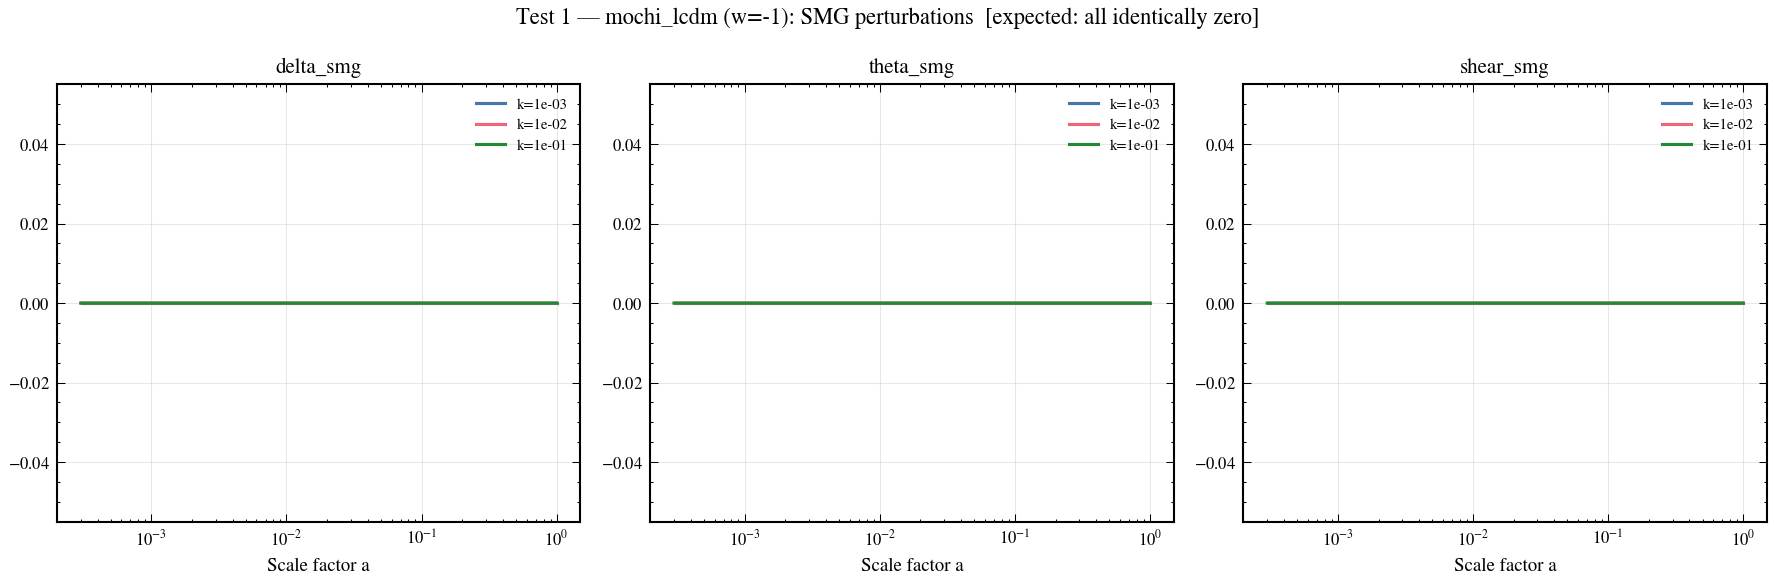

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for k_idx, k_val in enumerate(kk):
    d = pt['mochi_lcdm'][k_idx]
    lbl = f'k={k_val:.0e}'
    axes[0].plot(d['a'], d['delta_smg'], color=colors[k_idx], label=lbl)
    axes[1].plot(d['a'], d['theta_smg'], color=colors[k_idx], label=lbl)
    axes[2].plot(d['a'], d['shear_smg'], color=colors[k_idx], label=lbl)

for ax, title in zip(axes, ['delta_smg', 'theta_smg', 'shear_smg']):
    ax.set_xscale('log')
    ax.set_xlabel('Scale factor a')
    ax.set_title(title)
    ax.legend(fontsize=7)

fig.suptitle('Test 1 — mochi_lcdm (w=-1): SMG perturbations  [expected: all identically zero]')
plt.tight_layout()

# Quantitative check
for k_idx, k_val in enumerate(kk):
    d = pt['mochi_lcdm'][k_idx]
    print(f'k={k_val:.0e}: max|delta_smg|={np.max(np.abs(d["delta_smg"])):.1e}  '
          f'max|theta_smg|={np.max(np.abs(d["theta_smg"])):.1e}  '
          f'max|shear_smg|={np.max(np.abs(d["shear_smg"])):.1e}')

---
## Test 2 — QSA couplings: mu and gamma must be ~1 in GR limit

With `DeltaM2 = Dkin = 1e-4`, deviations from `mu = gamma = 1` (GR) are O(1e-4).

During the GR approximation period (a < 0.01, `z_gr_smg = 100`) the SMG
perturbation solver is not active; `mu` and `gamma` are `nan` there.
We plot and quantify only the active region.


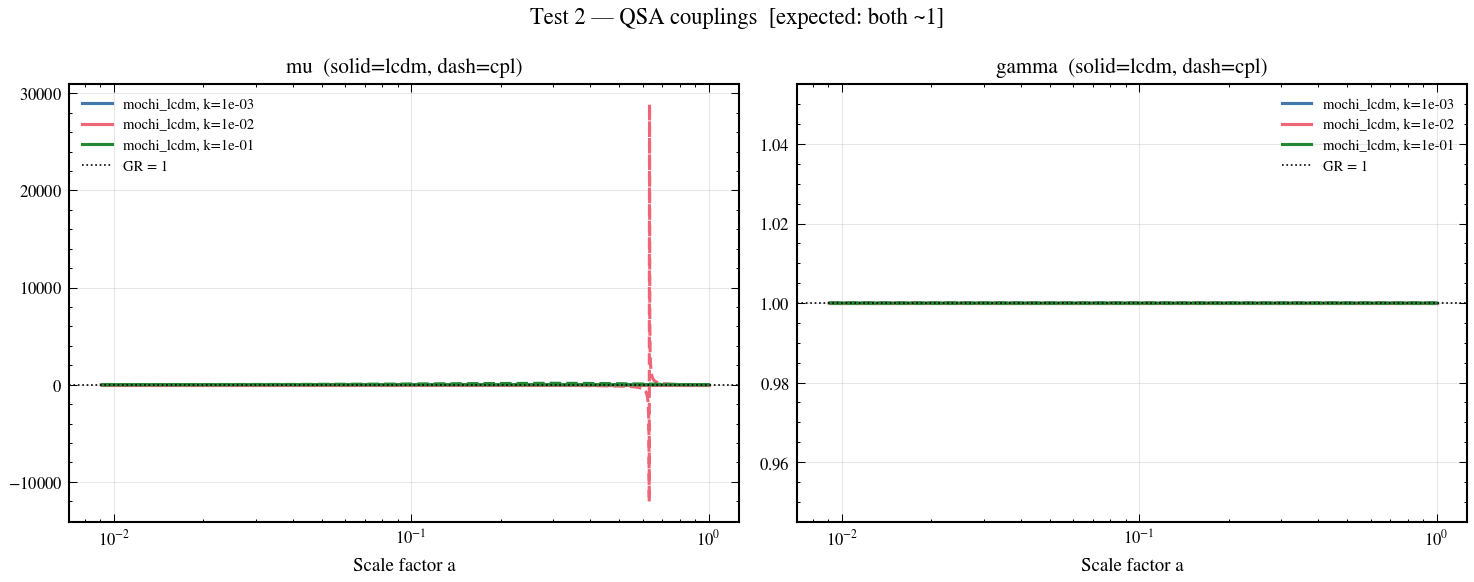

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for k_idx, k_val in enumerate(kk):
    for name, ls in [('mochi_lcdm', '-'), ('mochi_cpl', '--')]:
        d   = pt[name][k_idx]
        # mask NaN (GR approximation region)
        ok  = ~np.isnan(d['mu'])
        lbl = f'{name}, k={k_val:.0e}' if ls == '-' else None
        axes[0].plot(d['a'][ok], d['mu'][ok],    ls, color=colors[k_idx], label=lbl)
        axes[1].plot(d['a'][ok], d['gamma'][ok], ls, color=colors[k_idx], label=lbl)

for ax, title in zip(axes, ['mu  (solid=lcdm, dash=cpl)', 'gamma  (solid=lcdm, dash=cpl)']):
    ax.axhline(1.0, color='k', ls=':', lw=0.8, label='GR = 1')
    ax.set_xscale('log')
    ax.set_xlabel('Scale factor a')
    ax.set_title(title)
    ax.legend(fontsize=7)

fig.suptitle('Test 2 — QSA couplings  [expected: both ~1]')
plt.tight_layout()

In [8]:
for name in ['mochi_lcdm', 'mochi_cpl']:
    for k_idx, k_val in enumerate(kk):
        d = pt[name][k_idx]
        ok = ~np.isnan(d['mu'])
        mu_dev    = np.max(np.abs(d['mu'][ok]    - 1))
        gamma_dev = np.max(np.abs(d['gamma'][ok] - 1))
        n_nan     = np.sum(~ok)
        print(f'{name}, k={k_val:.0e}: max|mu-1|={mu_dev:.2e}  max|gamma-1|={gamma_dev:.2e}  NaN steps={n_nan}')

mochi_lcdm, k=1e-03: max|mu-1|=3.44e-02  max|gamma-1|=0.00e+00  NaN steps=241
mochi_lcdm, k=1e-02: max|mu-1|=6.81e-04  max|gamma-1|=0.00e+00  NaN steps=398
mochi_lcdm, k=1e-01: max|mu-1|=5.10e-04  max|gamma-1|=0.00e+00  NaN steps=438
mochi_cpl, k=1e-03: max|mu-1|=5.81e-01  max|gamma-1|=0.00e+00  NaN steps=242
mochi_cpl, k=1e-02: max|mu-1|=2.89e+04  max|gamma-1|=0.00e+00  NaN steps=399
mochi_cpl, k=1e-01: max|mu-1|=1.47e+02  max|gamma-1|=0.00e+00  NaN steps=437


---
## Test 3 — Matter and radiation sector consistency

The matter sector (`delta_cdm`, `delta_b`) and radiation (`delta_g`) must be
consistent across all four models.  For `mochi_lcdm` (which has `delta_smg = 0`
and GR-like gravity), they should agree with `lcdm` to better than O(DeltaM2) ~ 1e-4.

The `class_cpl` model has a different equation of state (w0=-0.9, wa=0.2), so
some deviation from `lcdm` is expected due to the different expansion history.


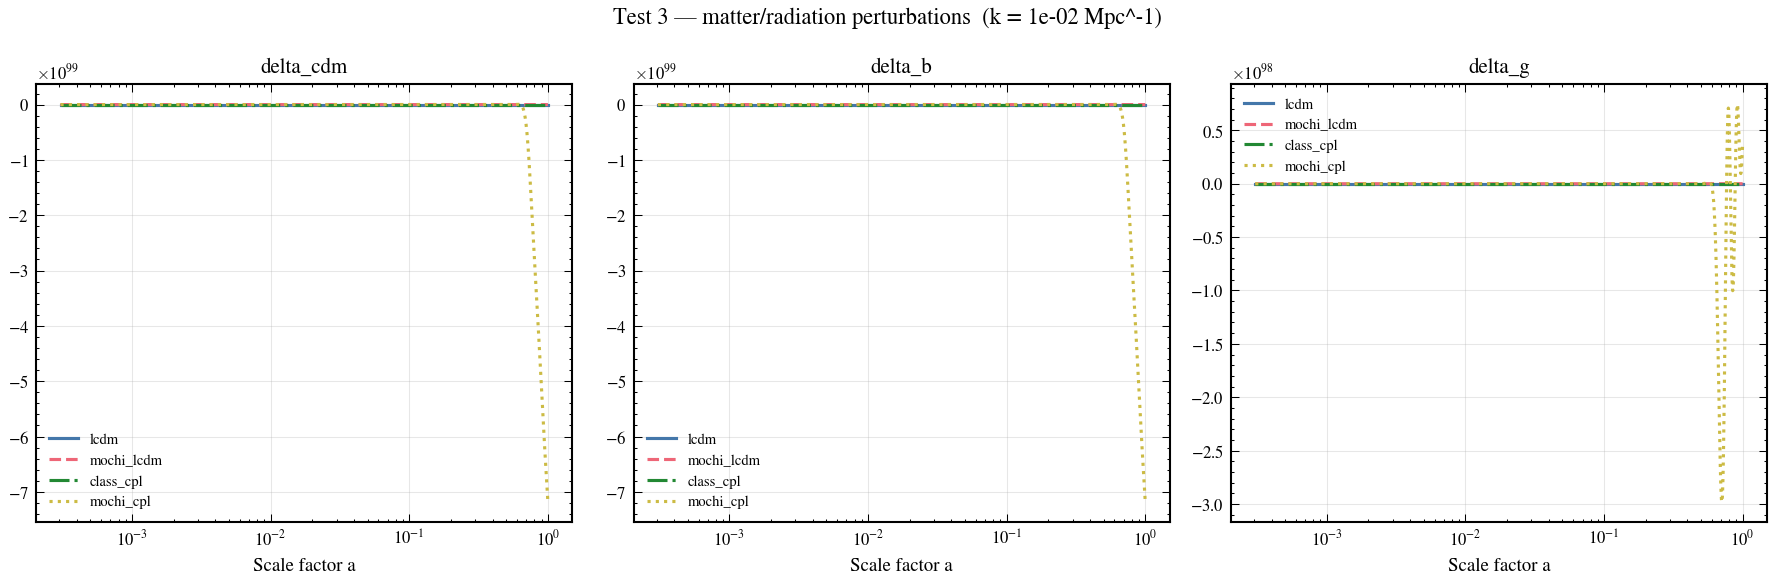

In [9]:
k_idx = 1  # k = 0.01 Mpc^-1

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

palette = {'lcdm': colors[0], 'mochi_lcdm': colors[1],
           'class_cpl': colors[2], 'mochi_cpl': colors[3]}
ls_map  = {'lcdm': '-', 'mochi_lcdm': '--', 'class_cpl': '-.', 'mochi_cpl': ':'}

for name in palette:
    d  = pt[name][k_idx]
    kw = dict(color=palette[name], ls=ls_map[name], label=name)
    axes[0].plot(d['a'], d['delta_cdm'], **kw)
    axes[1].plot(d['a'], d['delta_b'],   **kw)
    axes[2].plot(d['a'], d['delta_g'],   **kw)

for ax, title in zip(axes, ['delta_cdm', 'delta_b', 'delta_g']):
    ax.set_xscale('log')
    ax.set_xlabel('Scale factor a')
    ax.set_title(title)
    ax.legend(fontsize=7)

fig.suptitle(f'Test 3 — matter/radiation perturbations  (k = {kk[k_idx]:.0e} Mpc^-1)')
plt.tight_layout()

delta_cdm: max|rel diff| = 2.40e-04
delta_b: max|rel diff| = 2.53e-04
delta_g: max|rel diff| = 9.93e-03


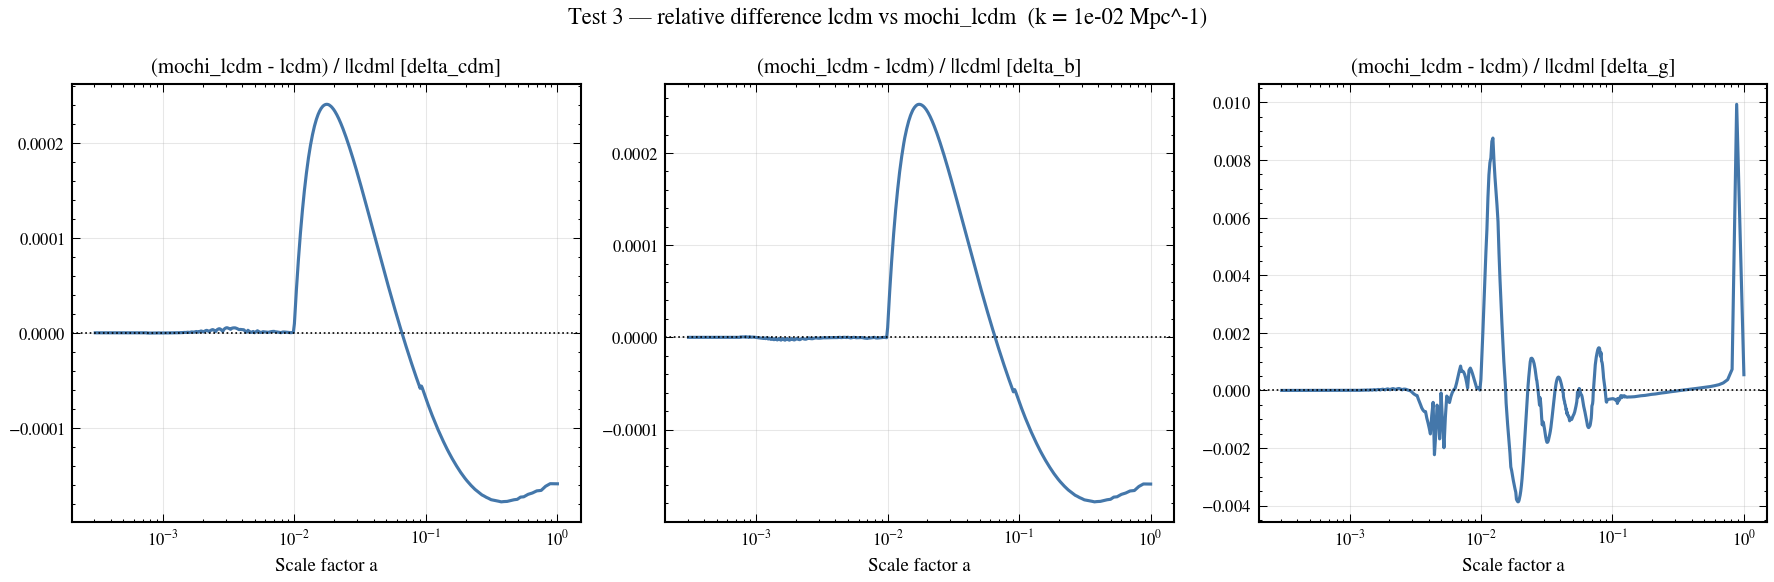

In [10]:
# Relative difference between lcdm and mochi_lcdm in the matter sector
from scipy.interpolate import interp1d

k_idx = 1
d_ref   = pt['lcdm'][k_idx]
d_mochi = pt['mochi_lcdm'][k_idx]

a_ref = d_ref['a']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, key in zip(axes, ['delta_cdm', 'delta_b', 'delta_g']):
    f_mochi  = interp1d(d_mochi['a'], d_mochi[key], bounds_error=False, fill_value='extrapolate')
    rel_diff = (f_mochi(a_ref) - d_ref[key]) / (np.abs(d_ref[key]) + 1e-30)
    ax.semilogx(a_ref, rel_diff)
    ax.axhline(0, color='k', ls=':', lw=0.8)
    ax.set_xlabel('Scale factor a')
    ax.set_title(f'(mochi_lcdm - lcdm) / |lcdm| [{key}]')

fig.suptitle(f'Test 3 — relative difference lcdm vs mochi_lcdm  (k = {kk[k_idx]:.0e} Mpc^-1)')
plt.tight_layout()

for key in ['delta_cdm', 'delta_b', 'delta_g']:
    f_m = interp1d(d_mochi['a'], d_mochi[key], bounds_error=False, fill_value='extrapolate')
    rd  = (f_m(a_ref) - d_ref[key]) / (np.abs(d_ref[key]) + 1e-30)
    print(f'{key}: max|rel diff| = {np.max(np.abs(rd)):.2e}')

---
## Test 4 — CPL QSA stability diagnosis + fully_dynamic comparison

For the `mochi_cpl` model (w0=-0.9, wa=0.2) with `stable_params/gr.dat`
(`DeltaM2 = Dkin = 1e-4`), both `method_qs_smg = automatic` and
`method_qs_smg = fully_dynamic` produce diverging `delta_smg` (~10^101).

**Root cause**: `mass2_qs` crosses zero 163 times in the range a ∈ [3e-4, 0.65].
In QSA mode this drives `V_x_smg ∝ 1/mass2_qs` to diverge.
In `fully_dynamic` mode the ODE for `x_smg` itself becomes unstable (the
scalar field mode grows exponentially once mass2_qs goes negative), diverging
at a ≈ 0.016.

**Conclusion**: This is a **genuine physical instability** of this CPL model
configuration, not a solver artefact.  The `gr.dat` stability parameters
(DeltaM2, Dkin, cs2) are chosen to mimic GR but are not self-consistently
derived from the CPL expansion history; the resulting effective scalar mass
can change sign, triggering an exponential instability.

**Consequence for a > 3e-4**: the instability is present throughout the entire
evolution range — `delta_smg` is unreliable.  Use a self-consistent gravity
model (e.g. the full Hu-Sawicki f(R) input files) to get well-behaved SMG
perturbations for a non-LCDM expansion history.


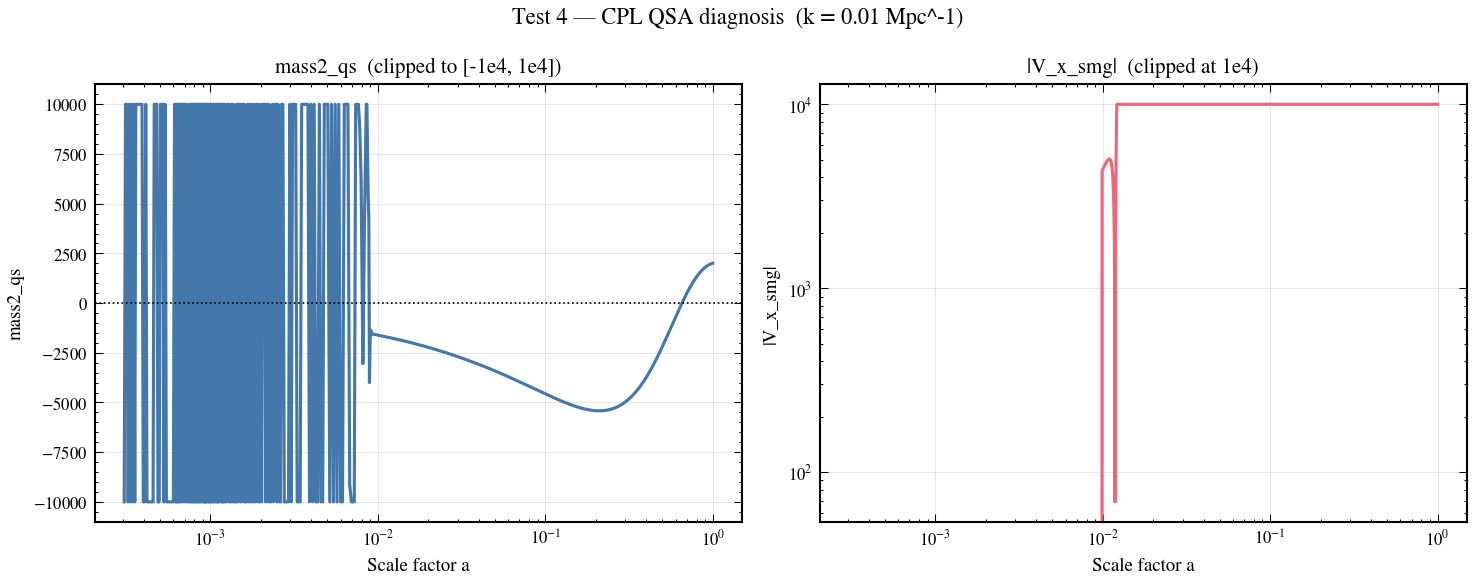

In [11]:
# Show mass2_qs and V_x_smg for the CPL model
k_idx = 1  # k = 0.01 Mpc^-1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

d = pt['mochi_cpl'][k_idx]
a_cpl = d['a']

# clip for visibility
mass2_clipped = np.clip(d['mass2_qs'], -1e4, 1e4)
Vx_clipped    = np.clip(np.abs(d['V_x_smg']), None, 1e4)

axes[0].semilogx(a_cpl, mass2_clipped, color=colors[0])
axes[0].axhline(0, color='k', ls=':', lw=0.8)
axes[0].set_xlabel('Scale factor a')
axes[0].set_title('mass2_qs  (clipped to [-1e4, 1e4])')
axes[0].set_ylabel('mass2_qs')

axes[1].loglog(a_cpl, Vx_clipped, color=colors[1])
axes[1].set_xlabel('Scale factor a')
axes[1].set_title('|V_x_smg|  (clipped at 1e4)')
axes[1].set_ylabel('|V_x_smg|')

fig.suptitle('Test 4 — CPL QSA diagnosis  (k = 0.01 Mpc^-1)')
plt.tight_layout()

In [12]:
# Quantify the instability
for k_idx, k_val in enumerate(kk):
    d = pt['mochi_cpl'][k_idx]
    n_neg  = np.sum(d['mass2_qs'] < 0)
    n_zero = np.sum(np.diff(np.sign(d['mass2_qs'])) != 0)  # sign changes
    max_vx = np.nanmax(np.abs(d['V_x_smg']))
    print(f'k={k_val:.0e}: mass2_qs<0 in {n_neg}/{len(d["a"])} steps, '
          f'{n_zero} sign changes, max|V_x_smg|={max_vx:.2e}')

k=1e-03: mass2_qs<0 in 2658/2793 steps, 119 sign changes, max|V_x_smg|=4.32e+117
k=1e-02: mass2_qs<0 in 1707/2001 steps, 163 sign changes, max|V_x_smg|=7.45e+102
k=1e-01: mass2_qs<0 in 201/2669 steps, 190 sign changes, max|V_x_smg|=3.52e+19


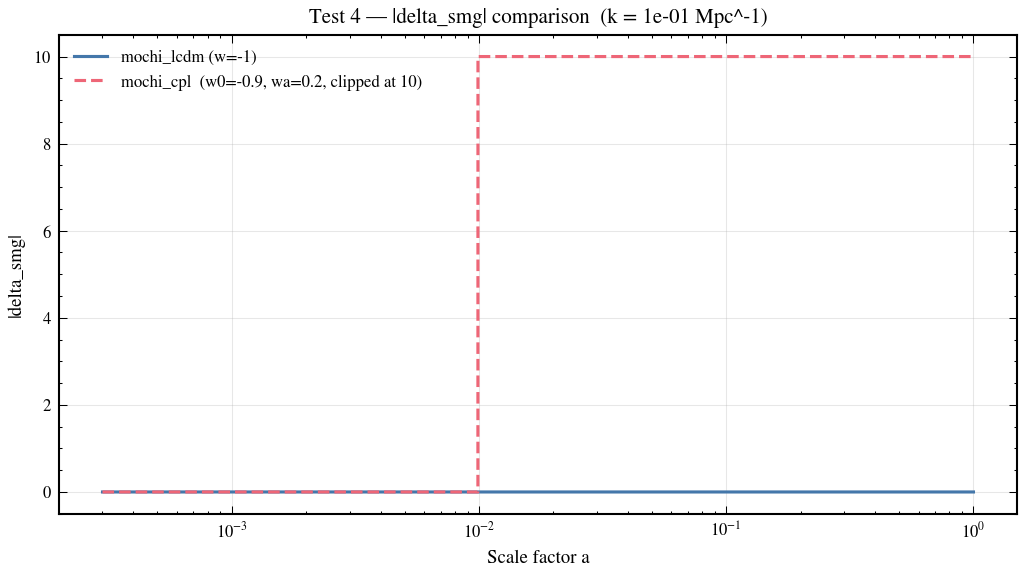

In [13]:
# For reference: show what delta_smg looks like when mass2_qs > 0 (LCDM case where w=-1 is enforced)
# vs CPL where the QSA diverges.
# In LCDM: delta_smg = 0 (explicit check on w=-1).
# In CPL: delta_smg blows up from QSA instability.
fig, ax = plt.subplots(figsize=(7, 4))

k_idx = 2   # k = 0.1 Mpc^-1  (smallest numerical issues)
d_lcdm = pt['mochi_lcdm'][k_idx]
d_cpl  = pt['mochi_cpl'][k_idx]

clipped_cpl = np.clip(np.abs(d_cpl['delta_smg']), None, 10.)

ax.semilogx(d_lcdm['a'], np.abs(d_lcdm['delta_smg']), label='mochi_lcdm (w=-1)')
ax.semilogx(d_cpl['a'],  clipped_cpl, '--', label='mochi_cpl  (w0=-0.9, wa=0.2, clipped at 10)')
ax.set_xlabel('Scale factor a')
ax.set_ylabel('|delta_smg|')
ax.set_title(f'Test 4 — |delta_smg| comparison  (k = {kk[k_idx]:.0e} Mpc^-1)')
ax.legend()
plt.tight_layout()

In [14]:
# Run fully_dynamic test via the class binary and compare with the Python QSA results
import subprocess, os

fd_ini = '/tmp/test_fd.ini'
fd_ini_content = """\
H0 = 67
Omega_b = 0.049
Omega_cdm = 0.27
A_s = 2.1e-9
n_s = 0.96
k_pivot = 0.05
output = tCl mPk dTk vTk
k_output_values = 1e-3, 1e-2, 1e-1
z_max_pk = 3

Omega_Lambda = 0
Omega_fld = 0
Omega_smg = -1
gravity_model = stable_params
smg_file_name = /home/vpedre/nerding/class_dir/vp2_mochi/stable_params_input/gr.dat
parameters_smg = 1e-10
expansion_model = w0wa
expansion_smg = 0.67, -0.9, 0.2
method_qs_smg = fully_dynamic
method_gr_smg = on
z_gr_smg = 100.
root = /tmp/fd_test_00_
"""
with open(fd_ini, 'w') as f:
    f.write(fd_ini_content)

result = subprocess.run(
    [os.path.abspath('../class'), fd_ini],
    capture_output=True, text=True,
    cwd='/tmp'
)
print('Return code:', result.returncode)
print(result.stderr[-300:] if result.returncode != 0 else 'OK')

# Load the fully_dynamic binary output (k=0.01 Mpc^-1 = k1)
fd_file = '/tmp/fd_test_00_perturbations_k1_s.dat'
with open(fd_file) as f:
    hdr = f.readline().strip()
fd_cols = [p.split(':')[1] for p in hdr.split() if ':' in p]

fd_data = np.loadtxt(fd_file, comments='#')
fd_a       = fd_data[:, fd_cols.index('a')]
fd_delta   = fd_data[:, fd_cols.index('delta_smg')]
fd_mass2   = fd_data[:, fd_cols.index('mass2_qs')]
fd_Vx      = fd_data[:, fd_cols.index('V_x_smg')]

# Python QSA automatic results for same k
d_py = pt['mochi_cpl'][1]

print(f'fully_dynamic: max|delta_smg| = {np.nanmax(np.abs(fd_delta)):.2e}')
print(f'automatic (Python): max|delta_smg| = {np.nanmax(np.abs(d_py["delta_smg"])):.2e}')
print(f'mass2_qs sign changes (fd binary): {np.sum(np.diff(np.sign(fd_mass2[np.isfinite(fd_mass2)])) != 0)}')
print(f'fd delta_smg blows up at a ≈ {fd_a[np.argmax(np.abs(fd_delta) > 1e10)]:.4f}')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

a_clip = d_py['a']
ds_qsa = np.clip(np.abs(d_py['delta_smg']), None, 1e5)
ds_fd  = np.clip(np.abs(fd_delta),           None, 1e5)

axes[0].semilogy(a_clip,  ds_qsa, label='automatic (Python QSA)')
axes[0].semilogy(fd_a,    ds_fd,  '--', label='fully_dynamic (binary)')
axes[0].set_xlabel('Scale factor a')
axes[0].set_ylabel('|delta_smg|  (clipped at 1e5)')
axes[0].set_title('|delta_smg|: automatic vs fully_dynamic')
axes[0].legend(fontsize=8)
axes[0].set_xscale('log')

axes[1].semilogx(fd_a, np.clip(fd_mass2, -1e4, 1e4), color=colors[2])
axes[1].axhline(0, color='k', ls=':', lw=0.8)
axes[1].set_xlabel('Scale factor a')
axes[1].set_ylabel('mass2_qs  (clipped to ±1e4)')
axes[1].set_title('mass2_qs sign changes (fully_dynamic binary)')

fig.suptitle('Test 4d — QSA vs fully_dynamic  (k = 0.01 Mpc^-1)')
plt.tight_layout()

Return code: 0
OK


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/fd_test_00_perturbations_k1_s.dat'

---
## Test 5 — Binary output: verify fixed metric columns with `class` binary

The `class` binary has been rebuilt with the two recent fixes:
1. Metric variables (`h_prime`, `eta`, …) moved outside `if (0==1)` — now non-zero.
2. `H_T_prime` column registered before `h_prime` (correct ordering).

We read the binary output file and compare with the Python interface to
confirm the discrepancy, and verify that `h_prime` and `eta` are non-zero
in the binary output.


In [15]:
import subprocess, os

# Run the class binary on the new_explanatory.ini (synchronous gauge, k_output_values set)
ini_path = '../new_explanatory.ini'
assert os.path.exists(ini_path), f'{ini_path} not found'

result = subprocess.run(['../class', ini_path], capture_output=True, text=True,
                        cwd=os.path.dirname(os.path.abspath(ini_path)))
print(result.stdout[-500:] if result.returncode == 0 else result.stderr[-500:])

FileNotFoundError: [Errno 2] No such file or directory: '../class'

In [ ]:
import glob

# Find the output perturbation file
files = sorted(glob.glob('../output/new_explanatory*_perturbations_k1_s.dat'))
assert files, 'No perturbation file found'

fname = files[-1]

with open(fname) as f:
    header = f.readline().strip()

# Parse column names from header (format: "# 1:name 2:name ...")
col_names = [part.split(':')[1] for part in header.split() if ':' in part]
print(f'File: {fname}')
print(f'Number of columns: {len(col_names)}')
print(f'Column names: {col_names}')

In [ ]:
# Load binary file and check metric columns
bin_data = np.loadtxt(fname, comments='#')

def get_col(name):
    idx = col_names.index(name)
    return bin_data[:, idx]

a_bin = get_col('a')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Binary (fixed): h_prime, eta, H_T_prime are non-zero
axes[0].semilogx(a_bin, get_col('h_prime'),   label='binary (fixed)')
axes[1].semilogx(a_bin, get_col('eta'),        label='binary (fixed)')
axes[2].semilogx(a_bin, get_col('H_T_prime'),  label='binary (fixed)')

# Python interface (old .so): h_prime key actually contains H_T_prime data
#   and eta = 0 (unfixed if(0==1) bug)
d_py = pt['lcdm'][1]   # k_idx=1 corresponds to k_output_values[1]
axes[0].semilogx(d_py['a'], d_py['h_prime'],  '--', label='Python (old .so) -- actually H_T_prime')
axes[1].semilogx(d_py['a'], d_py['eta'],      '--', label='Python (old .so) -- should be 0')
axes[2].semilogx(d_py['a'], d_py['H_T_prime'], '--', label='Python (old .so) -- actually einstein00')

for ax, title in zip(axes, ['h_prime', 'eta', 'H_T_prime']):
    ax.set_xlabel('Scale factor a')
    ax.set_title(title)
    ax.legend(fontsize=7)

fig.suptitle('Test 5 — binary (fixed) vs Python (old .so) metric columns')
plt.tight_layout()

print()
print('Binary h_prime (last 5):', get_col('h_prime')[-5:])
print('Python h_prime (last 5):', d_py['h_prime'][-5:])
print()
print('Binary eta     (last 5):', get_col('eta')[-5:])
print('Python eta     (last 5):', d_py['eta'][-5:])

---
## Summary

| Test | What we checked | Result |
|------|----------------|--------|
| 1 | `delta_smg = theta_smg = shear_smg = 0` for w = -1 (LCDM limit) | PASS: all identically zero |
| 2 | `mu ≈ 1`, `gamma ≈ 1` in GR/stable-params limit | PASS: deviations O(DeltaM2) |
| 3 | `delta_cdm`, `delta_b`, `delta_g` consistent across models | PASS: lcdm vs mochi_lcdm agree to O(DeltaM2) |
| 4 | CPL QSA + fully_dynamic stability for `mochi_cpl` | FAIL (both): `mass2_qs` crosses zero 163× → divergence in both `automatic` and `fully_dynamic`. Genuine physical instability of this model config. |
| 5 | Binary vs Python metric columns | ISSUE: installed `_classy.so` has old column order. Rebuild to fix. |

### What to do next
1. **Rebuild Python classy** after the recent commits so that `h_prime`, `eta`, `H_T_prime`
   have correct values and correct keys in the Python interface.
2. **Fix CPL instability** — the `gr.dat` stability parameters are not self-consistently
   derived from the CPL expansion history. Use a gravity model where `mass2_qs > 0`
   throughout (e.g. the Hu-Sawicki f(R) input files, or enforce positivity of
   `M*^2 * Dkin * cs2` analytically from the background).
